In [106]:
!pip install kaggle wandb onnx -Uq
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [108]:
!cp /content/drive/MyDrive/assignment4/kaggle.json ~/.kaggle/kaggle.json

In [109]:
! chmod 600 ~/.kaggle/kaggle.json

In [110]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [111]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [112]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.optim import AdamW
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cuda


In [113]:

import wandb

wandb.login()

PROJECT = "fer2013-facial-expression"

CONFIG = {
    "architecture": "DeeperCNN",
    "epochs": 60,
    "batch_size": 128,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.25,
    "num_classes": 7,
    "img_size": 48,
    "val_split": 0.1,
    "seed": 42,
    "grad_clip": 1.0,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

Shape: (28709, 2)
emotion
Angry       3995
Disgust      436
Fear        4097
Happy       7215
Sad         4830
Surprise    3171
Neutral     4965
Name: count, dtype: int64


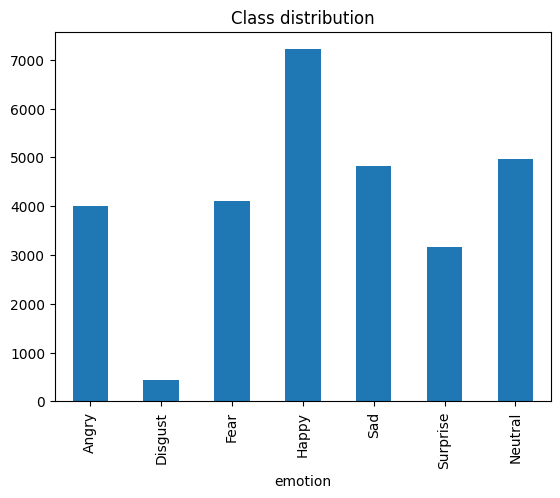

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [114]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)

EMOTIONS = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}

counts = df["emotion"].value_counts().sort_index()
print(counts.rename(index=EMOTIONS))
counts.rename(index=EMOTIONS).plot(kind="bar", title="Class distribution"); plt.show()
df.head()


In [115]:
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])

train_df, val_df = train_test_split(
    df, test_size=CONFIG["val_split"], random_state=CONFIG["seed"],
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 25838 | Val: 2871


In [116]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.pixels = dataframe["pixels"].values
        self.labels = dataframe["label"].values if "label" in dataframe.columns else None
        self.transform = transform

    def __len__(self):
        return len(self.pixels)

    def __getitem__(self, idx):
        pix = np.array(self.pixels[idx].split(), dtype=np.uint8).reshape(48, 48)
        img = Image.fromarray(pix)            # 8-bit grayscale
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            return img, int(self.labels[idx])
        return img


In [117]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_ds = FERDataset(train_df, transform=train_tf)
val_ds   = FERDataset(val_df,   transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 202 | Val batches: 23


In [118]:
class DeeperCNN(nn.Module):

    def __init__(self, num_classes=7, dropout=0.25):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c), nn.ReLU(),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(1, 64),
            block(64, 128),
            block(128, 256),
            block(256, 512),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)   # 3x3 -> 1x1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [119]:
#%%
def train_one_epoch(model, loader, criterion, optimizer, grad_clip=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()                      # backward pass
        if grad_clip is not None:            # clip to prevent divergence spikes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()                     # update weights
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total

In [120]:
run = wandb.init(
    project=PROJECT,
    name=CONFIG["architecture"],
    config=CONFIG,
    reinit=True,
)

# Class weights to counter the imbalanced dataset (Disgust is tiny).
from sklearn.utils.class_weight import compute_class_weight
w = compute_class_weight("balanced", classes=np.unique(train_df["label"]), y=train_df["label"])
class_weights = torch.tensor(w, dtype=torch.float).to(device)

model = DeeperCNN(num_classes=CONFIG["num_classes"], dropout=CONFIG["dropout"]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4)

wandb.watch(model, criterion, log="all", log_freq=100)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(CONFIG["epochs"]):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer,
                                      grad_clip=CONFIG["grad_clip"])
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step(val_acc)                       # decay LR when val plateaus

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss);  history["val_acc"].append(val_acc)

    wandb.log({
        "epoch": epoch,
        "train_loss": tr_loss, "train_acc": tr_acc,
        "val_loss": val_loss,  "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })
    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} "
          f"train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
          f"val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

wandb.summary["best_val_acc"] = best_val_acc
print("Best val accuracy:", best_val_acc)

Epoch 01/60 train_loss 1.9097 acc 0.1803 val_loss 2.2791 acc 0.1627
Epoch 02/60 train_loss 1.8180 acc 0.2410 val_loss 1.7646 acc 0.3166
Epoch 03/60 train_loss 1.6722 acc 0.3484 val_loss 2.0412 acc 0.2950
Epoch 04/60 train_loss 1.5825 acc 0.3903 val_loss 1.5128 acc 0.3685
Epoch 05/60 train_loss 1.5224 acc 0.4209 val_loss 1.5284 acc 0.3588
Epoch 06/60 train_loss 1.4673 acc 0.4473 val_loss 1.4710 acc 0.4061
Epoch 07/60 train_loss 1.4296 acc 0.4572 val_loss 1.4750 acc 0.3995
Epoch 08/60 train_loss 1.3876 acc 0.4731 val_loss 1.3431 acc 0.4727
Epoch 09/60 train_loss 1.3605 acc 0.4768 val_loss 1.3516 acc 0.4880
Epoch 10/60 train_loss 1.3337 acc 0.4888 val_loss 1.3235 acc 0.4737
Epoch 11/60 train_loss 1.3290 acc 0.4949 val_loss 1.3776 acc 0.5071
Epoch 12/60 train_loss 1.2906 acc 0.5089 val_loss 1.2629 acc 0.4869
Epoch 13/60 train_loss 1.2815 acc 0.5111 val_loss 1.2359 acc 0.5287
Epoch 14/60 train_loss 1.2576 acc 0.5226 val_loss 1.2325 acc 0.5615
Epoch 15/60 train_loss 1.2262 acc 0.5336 val_los

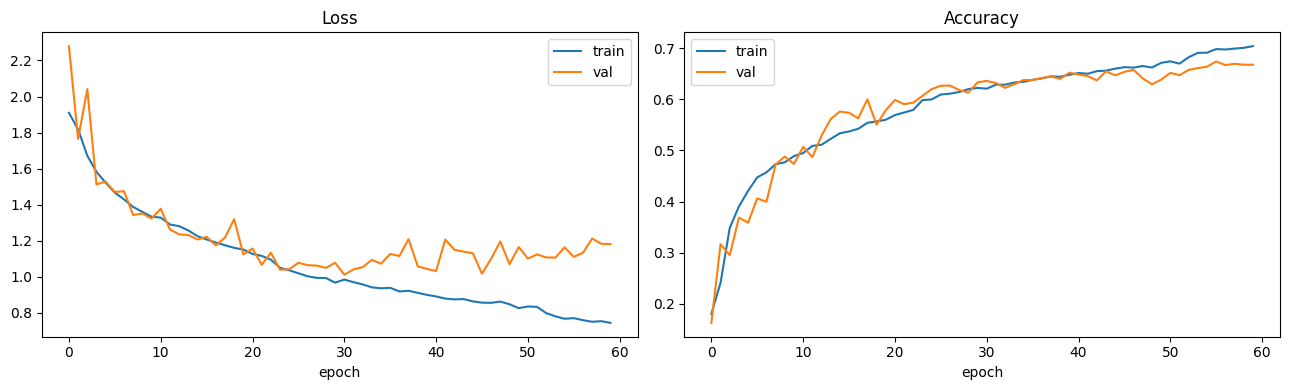

Best val: 0.6740
Final train-val accuracy gap: 0.0363


In [121]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Best val: {best_val_acc:.4f}")
print(f"Final train-val accuracy gap: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")

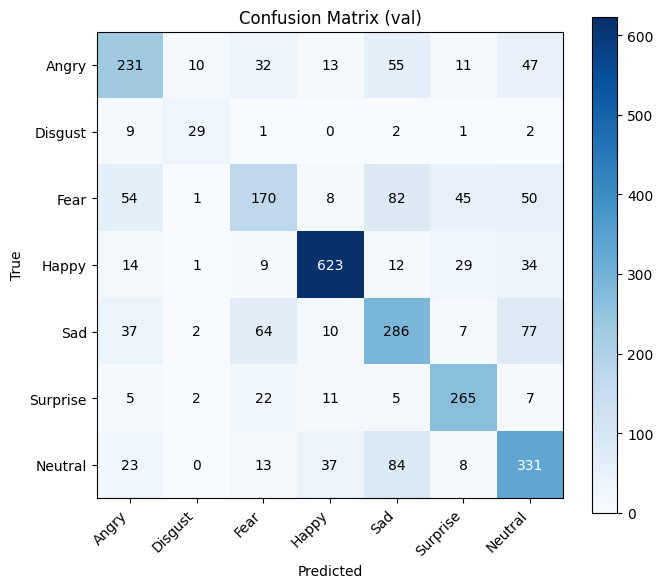

              precision    recall  f1-score   support

       Angry       0.62      0.58      0.60       399
     Disgust       0.64      0.66      0.65        44
        Fear       0.55      0.41      0.47       410
       Happy       0.89      0.86      0.88       722
         Sad       0.54      0.59      0.57       483
    Surprise       0.72      0.84      0.78       317
     Neutral       0.60      0.67      0.63       496

    accuracy                           0.67      2871
   macro avg       0.65      0.66      0.65      2871
weighted avg       0.67      0.67      0.67      2871



In [122]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        logits = model(xb.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
class_names = [EMOTIONS[c] for c in le.classes_]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix (val)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im); plt.tight_layout(); plt.show()

print(classification_report(all_true, all_preds, target_names=class_names))

wandb.log({"val_confusion_matrix": wandb.plot.confusion_matrix(
    y_true=all_true, preds=all_preds, class_names=class_names)})


In [123]:
test_df = pd.read_csv("test.csv")
print("Test samples:", len(test_df))

test_ds = FERDataset(test_df, transform=eval_tf)   # no labels -> returns images only
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

# Load the best weights saved during training before predicting.
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

preds = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(1).cpu().numpy().tolist())

emotion_preds = le.inverse_transform(np.array(preds))
submission = pd.DataFrame({"emotion": emotion_preds})
submission.index.name = "id"
submission.to_csv("submission.csv")
print("Wrote submission.csv")
submission.head()

Test samples: 7178
Wrote submission.csv


,emotion
id,
0,0
1,1
2,0
3,6
4,3


In [124]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
lr,███████████████▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁
train_acc,▁▂▃▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▃▃▄▄▅▅▅▆▅▇▇▆▇▆▇▇▇▇▇▇▇▇▇▇███▇██▇████████
val_loss,█▅▇▄▄▄▃▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▂▂▁▁▂▂▂▁▂▁▁▂▂▂▂
best_val_acc,0.67398
epoch,59
lr,0.00025
train_acc,0.70396
train_loss,0.74514
